# CS-363M Final Project

Wildlife strike damage prediction for the class competition. This notebook loads the FAA strike data, engineers features, tunes the probability threshold for balanced accuracy, and writes `submission.csv`.

In [18]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [19]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

### Process Files

In [20]:
TRAIN_PATH = Path("train.csv")
TEST_PATH = Path("test.csv")
SAMPLE_PATH = Path("sample_submission.csv")
SUBMISSION_PATH = Path("submission.csv")
RANDOM_STATE = 725
TARGET = "INDICATED_DAMAGE"
ID_COL = "INDEX_NR"

train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)

print(train.shape)
print(test.shape)
train.head()

(307178, 55)
(34131, 54)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


# Data Exploration

## Exploratory Data Analysis (EDA): Logic & Key Findings

Before building our predictive models, we need to understand the underlying "physics" of our dataset. Our EDA strategy focuses on three main areas: assessing data health (missing values and quality), evaluating the target variable distribution, and uncovering temporal and spatial patterns associated with wildlife strikes. 

Here is a summary of our findings based on the visual exploration below:

### 1. Severe Target Imbalance
* **Finding:** The `INDICATED_DAMAGE` target is highly skewed. The vast majority of reported strikes result in **0 (No Damage)**. 
* **Impact:** This extreme class imbalance means standard accuracy will be a misleading metric. We will need to rely on metrics like Balanced Accuracy or F1-Score, and we will likely need to perform probability threshold tuning on our final ensemble to effectively detect the rare "Damage" events.

### 2. The Danger Zone: Phase of Flight
* **Finding:** The overwhelming majority of strikes happen during **Approach, Landing Roll, Take-off Run, and Climb**. 
* **Logic:** This makes logical sense. These are the phases where aircraft are at lower altitudes (sharing airspace with birds) and operating at high engine thrust. We will use the `HEIGHT` and `SPEED` distributions to further map this low-altitude danger zone.

### 3. Seasonal Migration Trends
* **Finding:** The `INCIDENT_MONTH` distribution reveals a distinct spike in strikes during the **Summer and Fall**, with a noticeable drop during the Winter and Spring.
* **Logic:** This highly correlates with biological factors, specifically peak bird activity and fall migratory patterns. Month and Season will be critical temporal features for our model.

### 4. Data Quality & "The Unknowns"
* **Finding:** We have a significant amount of missing data across the board. Furthermore, visualizing high-cardinality features like `AIRCRAFT` and `OPERATOR` revealed that a massive chunk of our records are simply logged as "UNKNOWN". 
* **Impact:** The data quality here is quite noisy. Instead of dropping these rows, we will need robust imputation strategies (like treating "UNKNOWN" or "MISSING" as their own distinct categories) so tree-based models can learn if the *absence* of data is itself a predictor of damage.

### 5. Continuous Features & Correlations
* **Finding:** Our correlation heatmap and distribution plots for `SPEED` and `HEIGHT` will help us identify if certain kinetic thresholds (e.g., high speed + large bird species) act as strong numerical predictors before we pass them into our model.

Train dataset shape: (307178, 55)
Test dataset shape: (34131, 54)

Missing values in train (top 10):
BIRD_BAND_NUMBER    306465
ENG_4_POS           303909
ENROUTE_STATE       301832
PRECIPITATION       295966
ENG_3_POS           294822
LOCATION            267960
SPEED               212076
NUM_SEEN            208546
SKY                 162825
FLT                 161435
dtype: int64


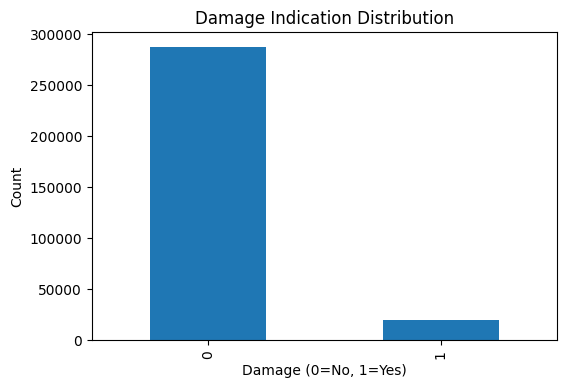

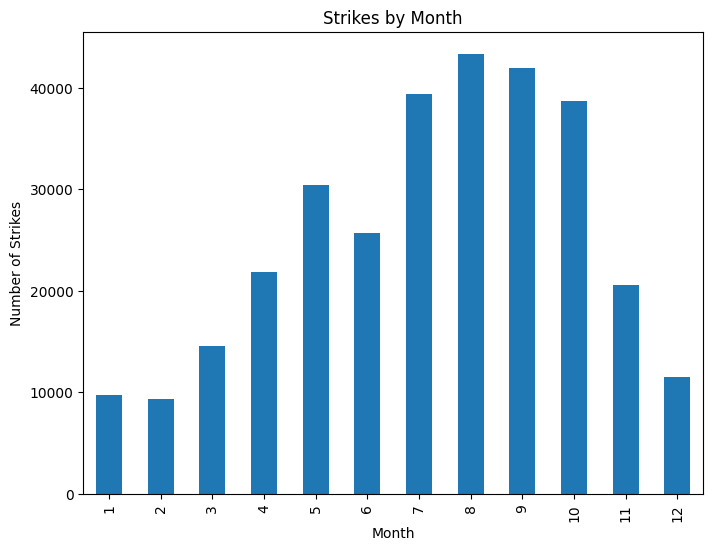

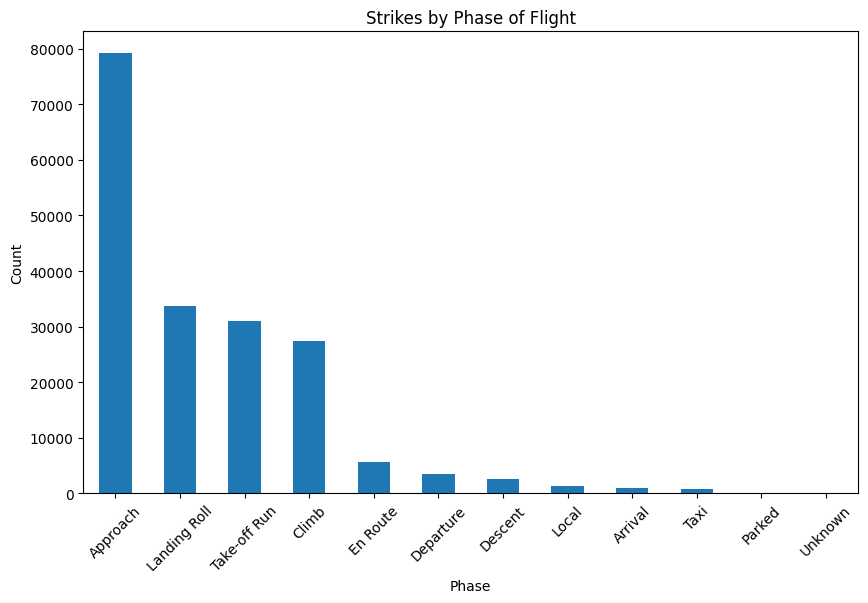

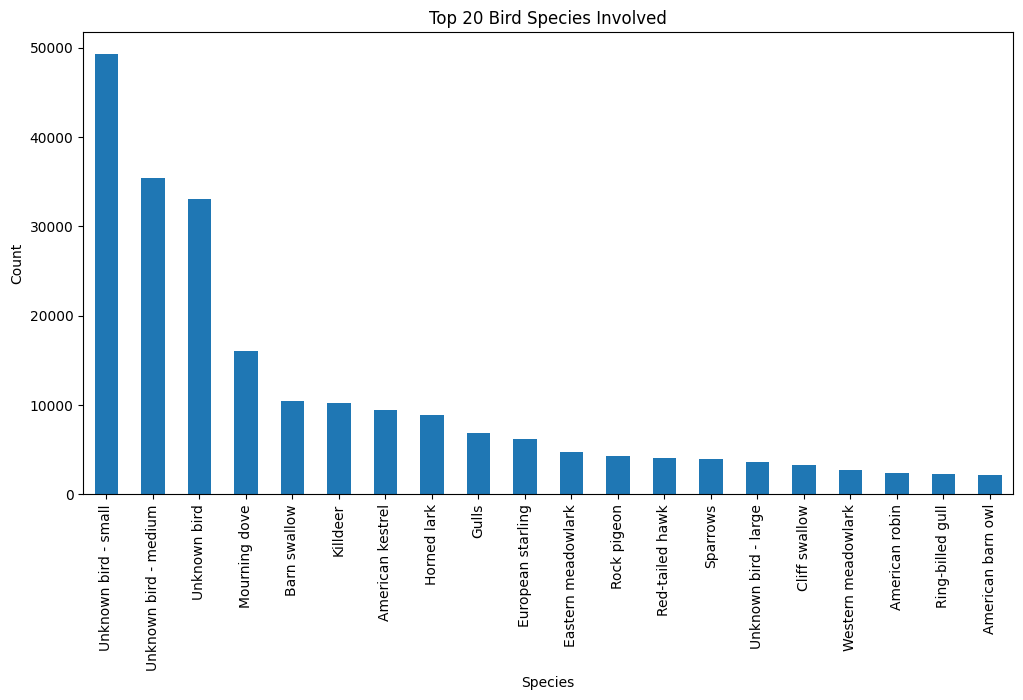

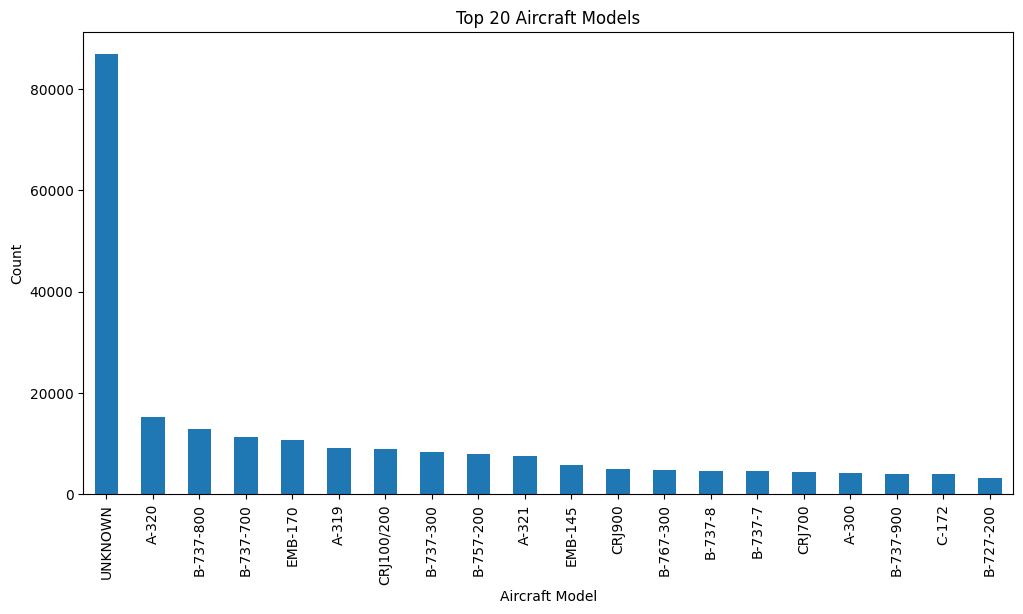

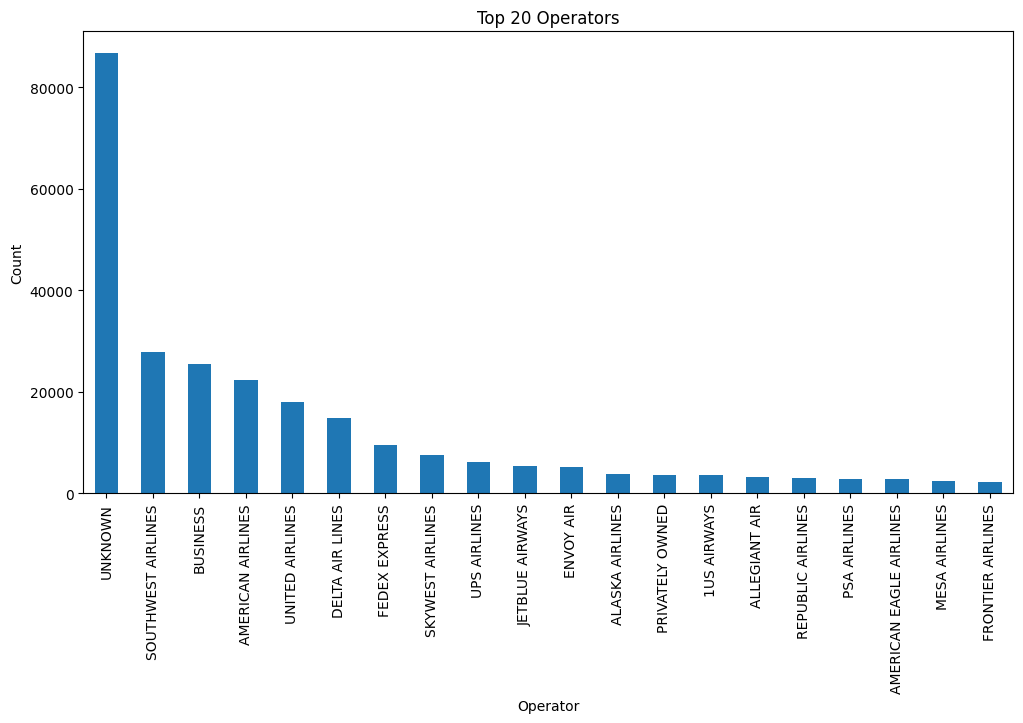

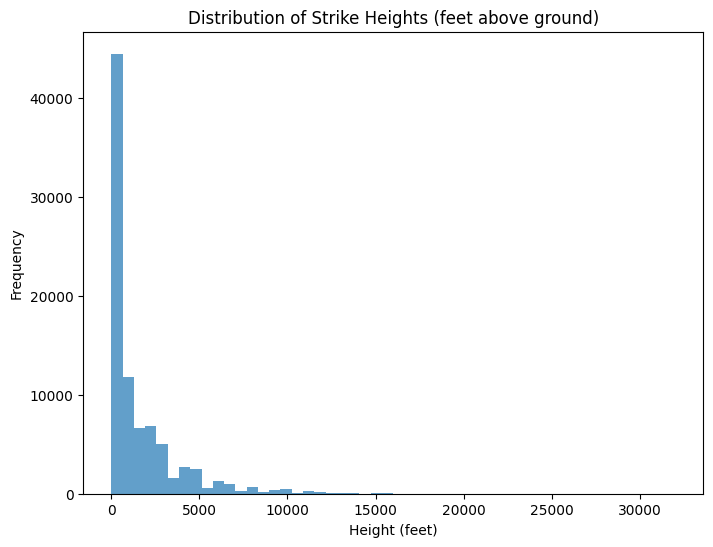

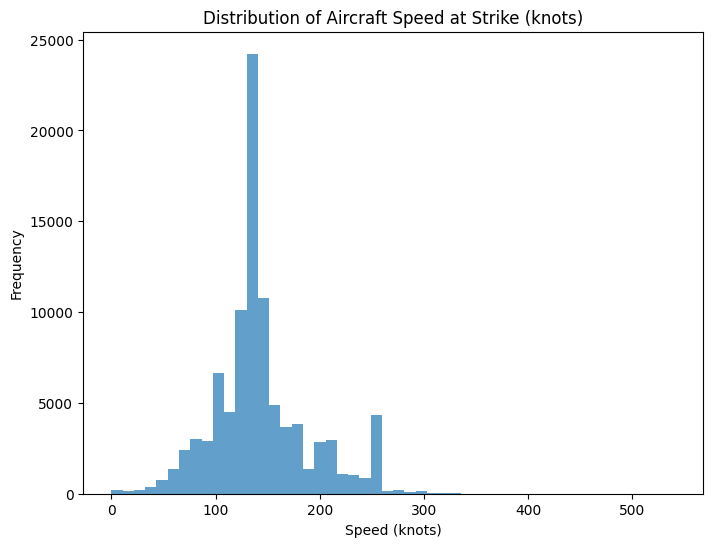

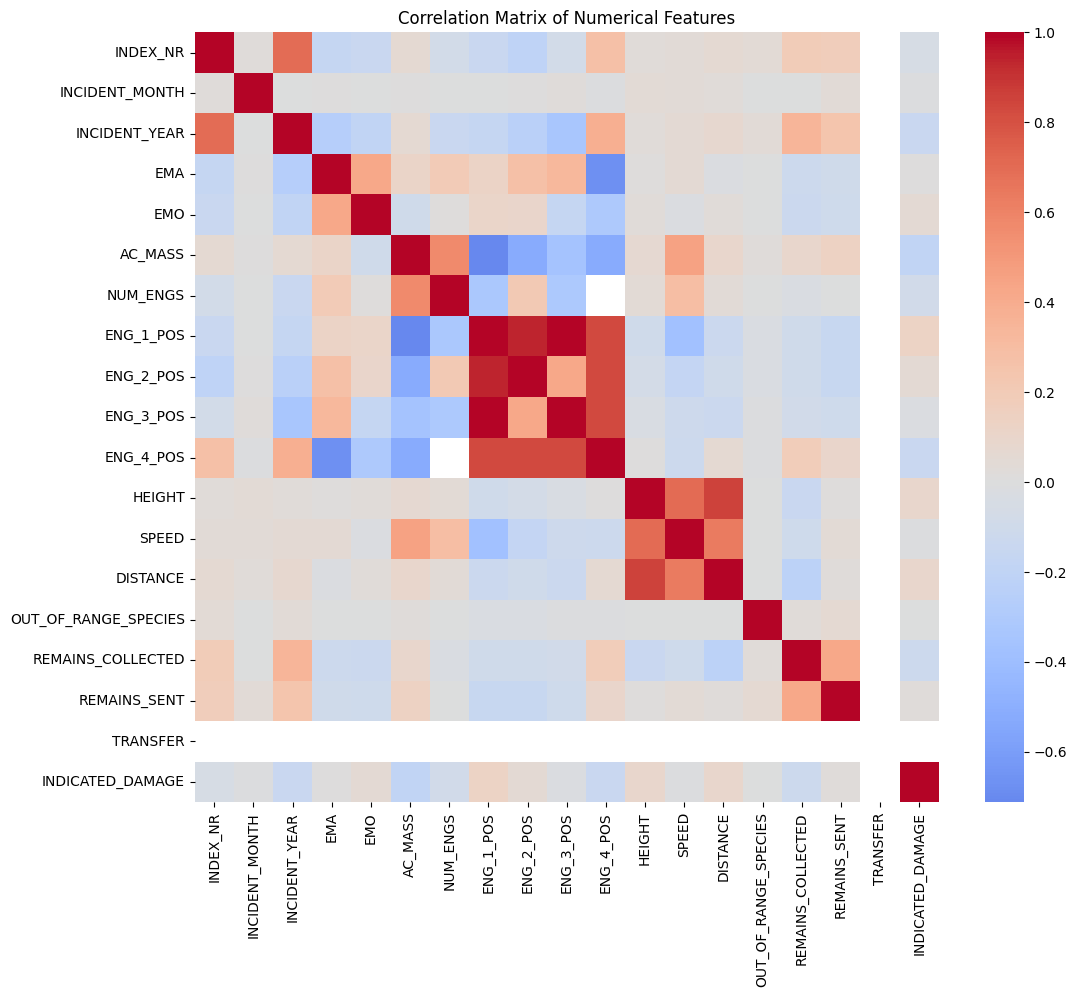

In [21]:
# Data Exploration and Visualization!!!!

# Basic dataset info
print("Train dataset shape:", train.shape)
print("Test dataset shape:", test.shape)
# Missing values
# we have lots of missing values in columns, this is importnant!
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print("\nMissing values in train (top 10):")
print(missing_train.head(10))


# Target variable distribution, this is important to understand the class balance!!!
plt.figure(figsize=(6,4))
train[TARGET].value_counts().plot(kind='bar')
plt.title('Damage Indication Distribution')
plt.xlabel('Damage (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()


# Specific feature distributions that are useful in data exploration
# Strikes by month, shows different birds in seasons
if 'INCIDENT_MONTH' in train.columns:
    plt.figure(figsize=(8,6))
    train['INCIDENT_MONTH'].value_counts().sort_index().plot(kind='bar')
    plt.title('Strikes by Month')
    plt.xlabel('Month')
    plt.ylabel('Number of Strikes')
    plt.show()
# Phase of flight, shows different risks at different phases of the flight
if 'PHASE_OF_FLIGHT' in train.columns:
    plt.figure(figsize=(10,6))
    train['PHASE_OF_FLIGHT'].value_counts().plot(kind='bar')
    plt.title('Strikes by Phase of Flight')
    plt.xlabel('Phase')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
# Top species, shows bird species in accidents
if 'SPECIES' in train.columns:
    plt.figure(figsize=(12,6))
    train['SPECIES'].value_counts().head(20).plot(kind='bar')
    plt.title('Top 20 Bird Species Involved')
    plt.xlabel('Species')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()
# Aircraft types, shows diff models, BUT mostly for UNKNOWN data! data quality is possibly really bad (bruh!)
if 'AIRCRAFT' in train.columns:
    plt.figure(figsize=(12,6))
    train['AIRCRAFT'].value_counts().head(20).plot(kind='bar')
    plt.title('Top 20 Aircraft Models')
    plt.xlabel('Aircraft Model')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()
# Operators, once again, data quality is maybe bad :(
if 'OPERATOR' in train.columns:
    plt.figure(figsize=(12,6))
    train['OPERATOR'].value_counts().head(20).plot(kind='bar')
    plt.title('Top 20 Operators')
    plt.xlabel('Operator')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()
# Height distribution, shows average height for strikes!
if 'HEIGHT' in train.columns:
    height_data = train[train['HEIGHT'] > 0]['HEIGHT']
    if not height_data.empty:
        plt.figure(figsize=(8,6))
        plt.hist(height_data, bins=50, alpha=0.7)
        plt.title('Distribution of Strike Heights (feet above ground)')
        plt.xlabel('Height (feet)')
        plt.ylabel('Frequency')
        plt.show()
# Speed distribution, shows average speed for strikes
if 'SPEED' in train.columns:
    speed_data = train['SPEED'].dropna()
    if not speed_data.empty:
        plt.figure(figsize=(8,6))
        plt.hist(speed_data, bins=50, alpha=0.7)
        plt.title('Distribution of Aircraft Speed at Strike (knots)')
        plt.xlabel('Speed (knots)')
        plt.ylabel('Frequency')
        plt.show()


# Big correlation heatmap to see any visual correlations for numeraical features
numerical_cols = train.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 1:
    corr_matrix = train[numerical_cols].corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()

# Data Preprocessing (includes both Cleaning and Feature Engineering)

## Data Preprocessing & Feature Engineering Logic

To achieve high balanced accuracy with gradient-boosting ensembles, our raw data must be mathematically formatted, purged of noise, and carefully engineered to prevent target leakage. Here is the logic driving our preprocessing pipeline:

### 1. Feature Trimming & Managing Unstructured Data
Tree-based models struggle with high-cardinality identifiers and raw text. 
* **Dropping Identifiers:** We remove features like `REG` (Tail Number) and `FLT` (Flight Number). These cause severe overfitting because the model attempts to memorize specific planes rather than learning generalizable physics.
* **Text Meta-Features:** Standard models cannot parse raw text columns like `REMARKS` or `COMMENTS`. Before dropping them, we extract their structural value (character count, word count). 
* ***Strategic Warning on Text Mining:*** We extract a boolean `HAS_DAMAGE_WORD` feature. However, because mechanic remarks are written *after* damage is discovered, relying heavily on this feature during training risks severe **target leakage**, which could inflate our validation scores but fail on real-world test data.

### 2. Translating Human Formats to Machine Math
We must convert string-based representations of magnitude into continuous numerical features so our models can find optimal split points.
* **Time Parsing:** We convert "HH:MM" strings into a single integer representing `minutes from midnight`.
* **Bucket Midpoints:** Text buckets (e.g., "11-100" birds) and Excel-corrupted dates (e.g., "10-feb" meaning 2-10 birds) are parsed into float midpoints (e.g., 55.5). This preserves the magnitude of the flock size.

### 3. Temporal & Missing Value Engineering
* **Cyclical Time:** We break down `INCIDENT_DATE` into day-of-week, quarter, and weekend flags to capture operational schedules and seasonal migration patterns.
* **Missingness as a Signal:** In messy datasets, the *absence* of data is often predictive. We generate explicit `_MISSING` boolean columns so the model can evaluate if a blank field correlates with strike severity.

### 4. Categorical Encoding Strategy
* **Ordinal vs. One-Hot Encoding:** Rather than using One-Hot Encoding (which would explode our feature space into thousands of columns and cause memory issues), we use Scikit-Learn's `OrdinalEncoder`. Tree algorithms are highly efficient at splitting ordinal integers. 
* **Handling Rare Categories:** We set a `min_frequency=10` in our encoder. This groups obscure, low-frequency categories (like rare airport codes) together, preventing the model from creating rules based on isolated outliers.


In [22]:


# Dropped these features because they will either cause overfitting (Identifiers),
# they are unstructured data (text), or they are primarily NaN
DROP_AFTER_FEATURES = [
    "INCIDENT_DATE", #redundant with month/year
    "LUPDATE", # can cause overfitting because recent update does not always equal damage
    "TIME", # redundant with time of day/ too specific
    "REMARKS", # text
    "COMMENTS", # text
    "LOCATION", # overfitting
    "REG", # ID overfitting
    "FLT", # irrelevant to birdstrikes
    "BIRD_BAND_NUMBER", # very rare, typically NaN
]


# used a filter to see if the text features have these words. Used to create new feature
# "has_damage_word"
DAMAGE_KEYWORDS = re.compile(
    r"damage|damaged|dent|dented|crack|cracked|hole|bent|broke|broken|"
    r"shatter|shattered|replace|replaced|repair|repaired|destroy",
    re.IGNORECASE,
)


# Tree models require numeric inputs. This function extracts the hour/minute 
# from string format and converts it into a continuous integer feature (minutes 
# from midnight) so the model can evaluate time mathematically.
def parse_time_to_minutes(value):
    if pd.isna(value):
        return np.nan
    match = re.match(r"^\s*(\d{1,2}):(\d{2})\s*$", str(value))
    if not match:
        return np.nan
    hour, minute = int(match.group(1)), int(match.group(2))
    if hour > 23 or minute > 59:
        return np.nan
    return hour * 60 + minute


# Converts messy string buckets (e.g., "11-100") and Excel auto-format date errors 
# (e.g., "10-feb" meaning 2-10) into continuous numerical midpoints. This preserves 
# the magnitude of the flock size for the model to split on.
def count_bucket_midpoint(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if not text:
        return np.nan
    normalized = text.lower()
    if normalized in {"1", "1.0"}:
        return 1.0
    if normalized in {"10-feb", "2-10", "02-oct"}:
        return 6.0
    if normalized == "11-100":
        return 55.5
    if normalized == "more than 100":
        return 150.0
    try:
        return float(text)
    except ValueError:
        return np.nan

# Packages the cleaning rules so they can be strictly applied to both the 
# training set and the holdout/test set without data leakage.
def make_preprocessor(features):
    numeric_cols = features.select_dtypes(exclude="object").columns.tolist()
    categorical_cols = features.select_dtypes(include="object").columns.tolist()

    return ColumnTransformer(
        transformers=[
            # Impute missing numbers with the median
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
                        (
                            "encoder",
                            # OrdinalEncoder is heavily preferred here over OneHotEncoder for 
                            # XGB/LGBM to avoid memory explosion. min_frequency=10 lumps rare 
                            # categories (like obscure airport codes) together to prevent overfitting.
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                encoded_missing_value=-1,
                                min_frequency=10,
                                max_categories=512,
                                dtype=np.float32,
                            ),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )




def add_features(df):
    engineered = df.copy()

    # Temporal Feature Extraction: Breaks down the date into cyclical components 
    # to capture seasonal bird migration patterns and weekend operational differences.
    incident_date = pd.to_datetime(engineered.get("INCIDENT_DATE"), format="%m/%d/%y", errors="coerce")
    engineered["INCIDENT_DAYOFWEEK"] = incident_date.dt.dayofweek
    engineered["INCIDENT_DAYOFYEAR"] = incident_date.dt.dayofyear
    engineered["INCIDENT_QUARTER"] = incident_date.dt.quarter
    engineered["INCIDENT_IS_WEEKEND"] = incident_date.dt.dayofweek.isin([5, 6]).astype("int8")

    # Administrative Timeframe Features
    last_update = pd.to_datetime(engineered.get("LUPDATE"), format="%m/%d/%y", errors="coerce")
    engineered["LUPDATE_YEAR"] = last_update.dt.year
    engineered["LUPDATE_MONTH"] = last_update.dt.month
    engineered["DAYS_TO_UPDATE"] = (last_update - incident_date).dt.days

    # Apply Time Parsing
    time_minutes = engineered.get("TIME", pd.Series(index=engineered.index, dtype="object")).map(parse_time_to_minutes)
    engineered["TIME_MINUTES"] = time_minutes
    engineered["TIME_HOUR"] = np.floor(time_minutes / 60)
    engineered["TIME_KNOWN"] = time_minutes.notna().astype("int8")

    # Apply Bucket Midpoint Parsing
    for col in ["NUM_SEEN", "NUM_STRUCK"]:
        if col in engineered:
            engineered[f"{col}_MIDPOINT"] = engineered[col].map(count_bucket_midpoint)


    # Reducing Feature count by 2 because their numeric order maintains relationship
    if "SIZE" in engineered:
        size_map = {"Small": 1, "Medium": 2, "Large": 3}
        engineered["SIZE_ORDINAL"] = engineered["SIZE"].map(size_map)

    for col in df.columns:
        if col not in {TARGET, ID_COL}:
            engineered[f"{col}_MISSING"] = engineered[col].isna().astype("int8")


    # Text Meta-Features: Extracts basic structure from text before dropping it
    for col in ["REMARKS", "COMMENTS", "LOCATION"]:
        if col in engineered:
            text = engineered[col].fillna("").astype(str)
            engineered[f"{col}_LEN"] = text.str.len()
            engineered[f"{col}_WORDS"] = text.str.split().str.len()
            engineered[f"{col}_HAS_DAMAGE_WORD"] = text.str.contains(DAMAGE_KEYWORDS).astype("int8")

    # Categorical Cleanup: Standardizes strings (upper case, stripped) to prevent 
    # the model from treating "Boeing" and " BOEING " as two different categories.
    for col in engineered.select_dtypes(include="object").columns:
        engineered[col] = engineered[col].fillna("MISSING").astype(str).str.strip().str.upper()
        engineered.loc[engineered[col].eq(""), col] = "MISSING"

    # Drop the raw columns that have now been engineered into safe formats
    return engineered.drop(columns=[col for col in DROP_AFTER_FEATURES if col in engineered.columns], errors="ignore")


## Preprocessing Driver

In [23]:

# Feature engineering
y = train[TARGET].astype(int)
X = add_features(train.drop(columns=[TARGET]))
X_test = add_features(test)
test_ids = test[ID_COL]

X = X.drop(columns=[ID_COL], errors="ignore")
X_test = X_test.drop(columns=[ID_COL], errors="ignore")
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Processing the actual data (including cleaning)
preprocessor = make_preprocessor(X_train)
X_train_prepared = preprocessor.fit_transform(X_train)
X_valid_prepared = preprocessor.transform(X_valid)


# Training the Model

## Model Training & Optimization Strategy

With our data properly preprocessed, we are using a **Histogram-based Gradient Boosting** ensemble. This algorithm is highly efficient for tabular data and handles our ordinal variables natively. To maximize our predictive power and combat the severe target imbalance, our training pipeline relies on three core strategies:

### 1. Ensemble Diversity (The "Two-Model" Approach)
Instead of relying on a single model, we are training two models with distinct hyperparameters and averaging their probability outputs. This reduces variance and prevents the model from memorizing the training data.
* **Model 1 (Conservative):** Uses smaller trees (`max_leaf_nodes=31`), a slower learning rate, and higher L2 regularization. This model acts as our stable baseline, focused on generalizing broader patterns without overfitting.
* **Model 2 (Complex):** Uses larger trees (`max_leaf_nodes=127`) to capture deep, complex interactions between features, but constrains overfitting by requiring more samples per leaf (`min_samples_leaf=30`) and using early stopping.


### 2. Dynamic Probability Thresholding 
By default, machine learning models predict a "1" if the probability is $\ge 0.50$. For highly imbalanced data, this default is almost never optimal. 
* Rather than accepting the default, our pipeline extracts the raw probabilities from the ensemble.
* The `best_threshold` function then simulates hundreds of potential cutoff points (from 0.01 to 0.99).
* It evaluates each threshold against our validation set to find the exact boundary that mathematically maximizes our **Balanced Accuracy Score**.

In [24]:
# train 2 separate models to use for ensemble voting method
# train 2 models to make an ensemble, then we get the best threshold 
MODEL_CONFIGS = [
    {
        "loss": "log_loss",
        "learning_rate": 0.04, # lower rate to reduce overfitting
        "max_iter": 600, # more iterations to allow better convergence
        "max_leaf_nodes": 31, # smaller trees to reduce overfitting
        "l2_regularization": 0.05, # stronger regularization to combat overfitting
        "early_stopping": True, # enable early stopping to prevent overfitting
        "validation_fraction": 0.12, # use a portion of training data for early stopping validation
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
    },
    {
        "loss": "log_loss", 
        "learning_rate": 0.06, # slightly higher learning rate for a different convergence path
        "max_iter": 450, # fewer iterations for a different convergence path and reduce overfitting
        "max_leaf_nodes": 127, # larger trees to alolw for a different convergence path
        "min_samples_leaf": 30, # require more samples per leaf to reduce overfitting
        "l2_regularization": 0.01, # moderate regularization to balance bias and variance
        "early_stopping": True,
        "validation_fraction": 0.12,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
    },
]

# Create and train the ensemble models based on the configurations defined above
def make_models():
    return [HistGradientBoostingClassifier(**config) for config in MODEL_CONFIGS]

# Returns a list of the ensemble models
def ensemble_probabilities(models, features):
    probabilities = [model.predict_proba(features)[:, 1] for model in models]
    return np.mean(probabilities, axis=0)

# Finds the best threshold for converting probabilities to binary predictions based on balanced accuracy
def best_threshold(y_true, probabilities):
    candidates = np.unique(np.r_[np.linspace(0.03, 0.97, 189), np.quantile(probabilities, np.linspace(0.01, 0.99, 99))])
    scores = [
        (balanced_accuracy_score(y_true, probabilities >= threshold), threshold) # calculate balanced accuracy for each threshold
        for threshold in candidates
    ]
    score, threshold = max(scores, key=lambda item: item[0]) # get the best score and corresponding threshold
    return float(threshold), float(score)

## Training Driver

In [25]:
# Run the methods we made above to train teh models

# Train the ensemble models on the prepared training data
models = make_models()
for model in models:
    model.fit(X_train_prepared, y_train)

# Evaluate the ensemble on the validation set using 0.5 threshold, then find the best threshold!
valid_probabilities = ensemble_probabilities(models, X_valid_prepared)
default_score = balanced_accuracy_score(y_valid, valid_probabilities >= 0.5)
threshold, tuned_score = best_threshold(y_valid, valid_probabilities)
valid_predictions = (valid_probabilities >= threshold).astype(int)

# Print out the results and evaluation metrics for the validation set
print(f"Training rows: {len(X_train):,} | validation rows: {len(X_valid):,}")
print(f"Target damage rate: {y.mean():.4%}")
print(f"Balanced accuracy at 0.50 threshold: {default_score:.5f}")
print(f"Best validation threshold: {threshold:.5f}")
print(f"Best validation balanced accuracy: {tuned_score:.5f}")
print(classification_report(y_valid, valid_predictions, digits=4))

Training rows: 245,742 | validation rows: 61,436
Target damage rate: 6.3569%
Balanced accuracy at 0.50 threshold: 0.86169
Best validation threshold: 0.44000
Best validation balanced accuracy: 0.86369
              precision    recall  f1-score   support

           0     0.9886    0.8759    0.9289     57531
           1     0.3178    0.8515    0.4628      3905

    accuracy                         0.8744     61436
   macro avg     0.6532    0.8637    0.6958     61436
weighted avg     0.9460    0.8744    0.8992     61436



In [26]:
# Train final models on full training data
final_preprocessor = make_preprocessor(X)
X_prepared = final_preprocessor.fit_transform(X)
X_test_prepared = final_preprocessor.transform(X_test)
# Train final models on full training data, this is to get the best performance!
final_models = make_models()
for model in final_models:
    model.fit(X_prepared, y)

# Predict on test data using tuned threshold
# this is where we get the final predictions for the final submission
test_probabilities = ensemble_probabilities(final_models, X_test_prepared)
test_predictions = (test_probabilities >= threshold).astype(int)

# Create and write teh submission file (we submit this!)
submission = pd.read_csv(SAMPLE_PATH)
submission[ID_COL] = test_ids.values
submission[TARGET] = test_predictions
submission.to_csv(SUBMISSION_PATH, index=False)

# Final thoughts, and the submission head(debugging the submission file)
print(f"Final Accuracy: {tuned_score:.5f} ")
submission.head()

Final Accuracy: 0.86369 


,INDEX_NR,INDICATED_DAMAGE
0,9000000,0
1,9000001,0
2,9000002,0
3,9000003,0
4,9000004,1
